Para rodar esse notebook, basta baixar o dataset disponível no Kaggle (https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud), fazer o upload para o Google Colab na aba de arquivos e notar que pode ser necessário mudar o path do arquivo CSV.

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [19]:
credit_card_dataset = pd.read_csv('creditcard.csv')

# Data Understanding

In [20]:
credit_card_dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [21]:
# Estrutura do DataFrame
credit_card_dataset.info()
print(credit_card_dataset.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [22]:
# Estatísticas descritivas
credit_card_dataset.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [23]:
credit_card_dataset['Class'].value_counts()
credit_card_dataset['Class'].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


A seguir, é possível observar que existe um grande desequilíbrio entre as classes. Isso pode tornar o modelo enviesado.

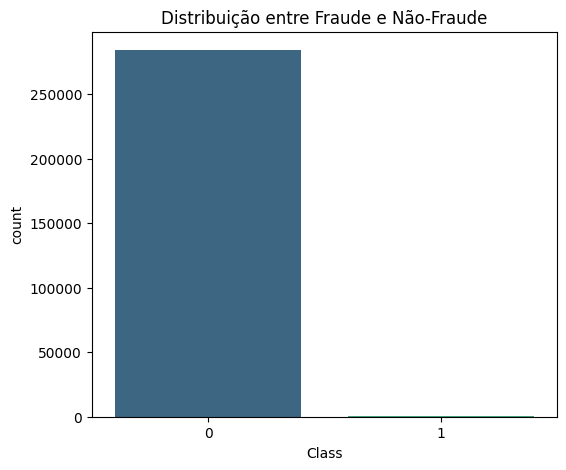

In [24]:
plt.figure(figsize=(6,5))
sns.countplot(x='Class', data=credit_card_dataset, hue='Class', palette='viridis', legend=False)
plt.title('Distribuição entre Fraude e Não-Fraude')
plt.show()

O mapa de calor a seguir demostra que existe pouca correlação entre as variáveis e a ocorrência de fraudes, o que sugere um fenômeno de natureza não linear.

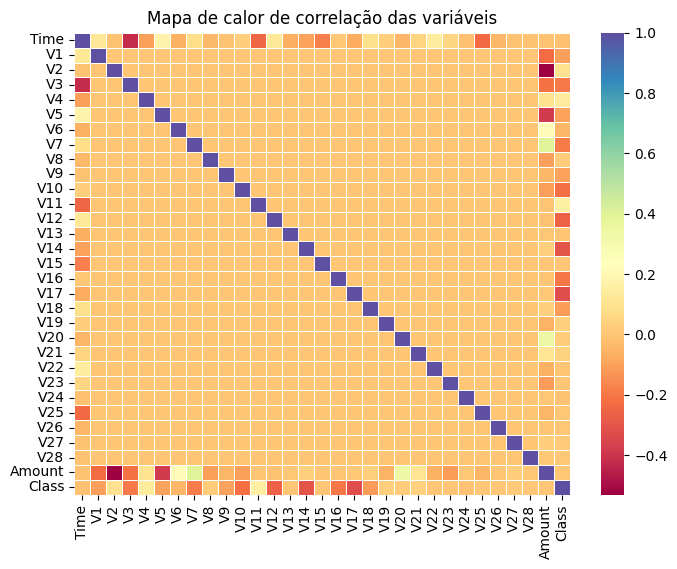

In [25]:
# Verifica a correlacao entre variaveis
plt.figure(figsize=(8,6))
sns.heatmap(credit_card_dataset.corr(), cmap='Spectral', linewidths=0.5)
plt.title("Mapa de calor de correlação das variáveis")
plt.show()

# Limpeza de Dados

In [26]:
# Verificando Valores Faltantes

print(credit_card_dataset.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [27]:
# Removendo valores duplicados
credit_card_dataset.drop_duplicates(inplace=True)

In [28]:
# Validando colunas
print("Valor Mínimo:", credit_card_dataset['Amount'].min())
print("Valor de tempo mínimo:", credit_card_dataset['Time'].min())

Valor Mínimo: 0.0
Valor de tempo mínimo: 0.0


In [29]:
# Garantindo que os valores para classe sejam apenas 0 ou 1
print("Classes:", credit_card_dataset['Class'].unique())

Classes: [0 1]


# EDA (Exploratory Data Analysis)

Verificando os níveis atuais de fraude


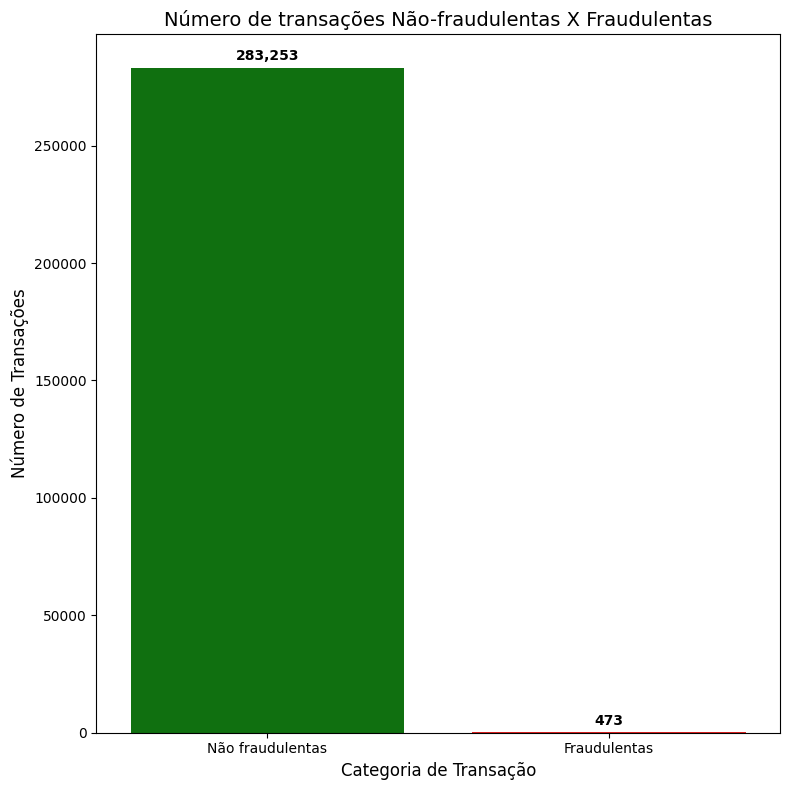

In [30]:
# Calculando o número de transações fraudulentas e não fraudulentas
fraud_count = credit_card_dataset['Class'].value_counts().reset_index()
fraud_count.columns = ['Class', 'NumTran']

# Altera o rotulo da classe para facilitar a leitura
fraud_count['Class'] = fraud_count['Class'].map({0: 'Não fraudulentas', 1: 'Fraudulentas'})

plt.figure(figsize=(8, 8))
ax = sns.barplot(
    x='Class',
    y='NumTran',
    hue='Class',
    data=fraud_count,
    palette=['green', 'red'],
)

#plot
for p in ax.patches:
    ax.annotate(
        format(int(p.get_height()), ','),
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 8),  # Pedding do texto
        textcoords='offset points',
        fontsize=10, weight='bold'
    )

plt.title("Número de transações Não-fraudulentas X Fraudulentas", fontsize=14)
plt.xlabel("Categoria de Transação", fontsize=12)
plt.ylabel("Número de Transações", fontsize=12)
plt.tight_layout()
plt.show()

Quando fraudes ocorrem com mais frequência?

Horários com mais fraudes:
Hora
11    53
2     48
17    28
dtype: int64


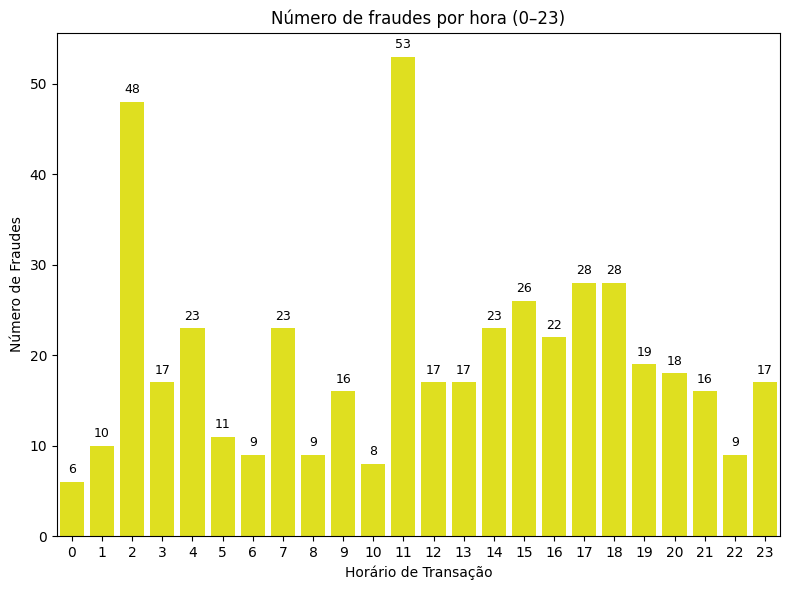

In [31]:
credit_card_dataset['Hora'] = (credit_card_dataset['Time'] // 3600) % 24

# Número de fraudes por hora
fraud_by_hour = (
    credit_card_dataset[credit_card_dataset['Class'] == 1]
    .groupby('Hora')
    .size()
    .reindex(range(24), fill_value=0)
)

# Mostra as 3 principais horas
print("Horários com mais fraudes:")
print(fraud_by_hour.sort_values(ascending=False).head(3))

# Grafico de Barra
plt.figure(figsize=(8,6))
ax = sns.barplot(x=fraud_by_hour.index, y=fraud_by_hour.values, color='yellow')

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', xytext=(0,4), textcoords='offset points', fontsize=9)

plt.title("Número de fraudes por hora (0–23)")
plt.xlabel("Horário de Transação")
plt.ylabel("Número de Fraudes")
plt.tight_layout()
plt.show()

Parece haver horários em que o número de fraudes aumenta de forma significativa. É possível observar que às 2 horas da manhã houve 48 fraudes, e 53 às 11 da manhã. Poderiam ser falhas na prestação do serviço devido a tempo ocioso por ser de madrugada ou horário de almoço, mas isso é só especulação.

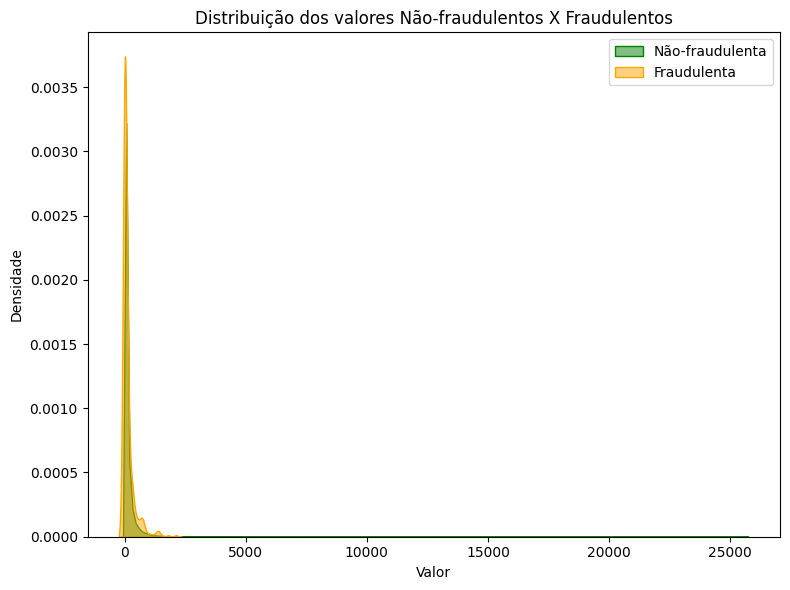

In [32]:
# Exemplo para a coluna Amount (Valor da transacao)
plt.figure(figsize=(8,6))
sns.kdeplot(
    data=credit_card_dataset[credit_card_dataset['Class'] == 0]['Amount'],
    label='Não-fraudulenta',
    fill=True,
    alpha=0.5,
    color='green'
)
sns.kdeplot(
    data=credit_card_dataset[credit_card_dataset['Class'] == 1]['Amount'],
    label='Fraudulenta',
    fill=True,
    alpha=0.5,
    color='orange'
)
plt.title("Distribuição dos valores Não-fraudulentos X Fraudulentos")
plt.xlabel("Valor")
plt.ylabel("Densidade")
plt.legend()
plt.tight_layout()
plt.show()

Dá para ver que o pico de transações fraudulentas é de valores baixos, bem semelhante ao de transações normais. Ou seja, o valor da transação por si só não é um bom preditor, já que não há uma correlação tão forte. A única conclusão é que fraudes são menos comuns em transações de grandes valores, muito possivelmente devido ao cuidado burococrático com esse tipo de transação.

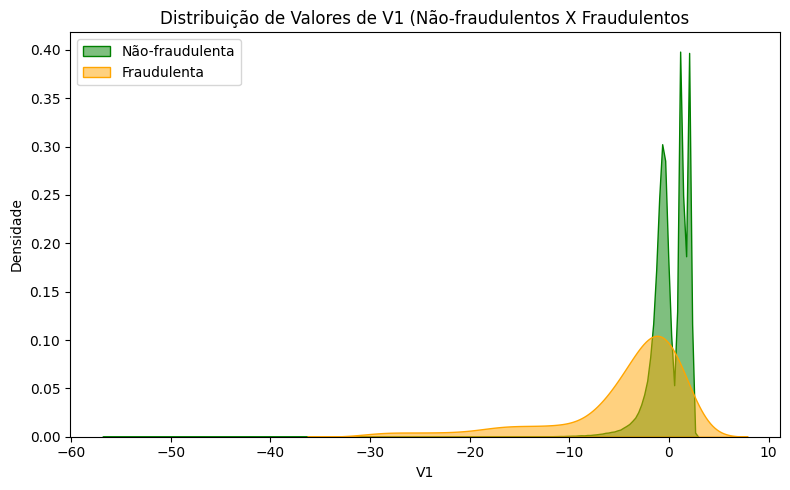

In [33]:
plt.figure(figsize=(8,5))
sns.kdeplot(
    data=credit_card_dataset[credit_card_dataset['Class'] == 0]['V1'],
    label='Não-fraudulenta',
    fill=True,
    alpha=0.5,
    color='green'
)
sns.kdeplot(
    data=credit_card_dataset[credit_card_dataset['Class'] == 1]['V1'],
    label='Fraudulenta',
    fill=True,
    alpha=0.5,
    color='orange'
)
plt.title("Distribuição de Valores de V1 (Não-fraudulentos X Fraudulentos")
plt.xlabel("V1")
plt.ylabel("Densidade")
plt.legend()
plt.tight_layout()
plt.show()

Esse dataset foi tratado antes com combinação linear de múltiplas variáveis para não expor os clientes em uma variável (PCA), então no gráfico é possível observar que existe algum padrão oculto que diferencia as duas classes.

# Modelo de Logistic Regression

In [34]:
# definindo y e x
X = credit_card_dataset.drop(columns=['Class', 'Time'])
y = credit_card_dataset['Class']

In [35]:
#dividindo entre treino e test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [36]:
#Treinando o modelo de regressao logistica

model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)

# Metodo de Treinamento
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)

In [37]:
# Previsões
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# Acurácia
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia: {accuracy:.4f}")

Acurácia: 0.9991


O valor de revocação é alto, mas enganoso, já que, como visto anteriormente nos gráficos de dispersão, o desequilíbrio entre classes enviesa o modelo. Essa ótica não é o foco dessa métrica, por isso não é adequada para esse tipo de dataset que não passou por algum tipo de pré-processamento para lidar com esse desequilíbrio.

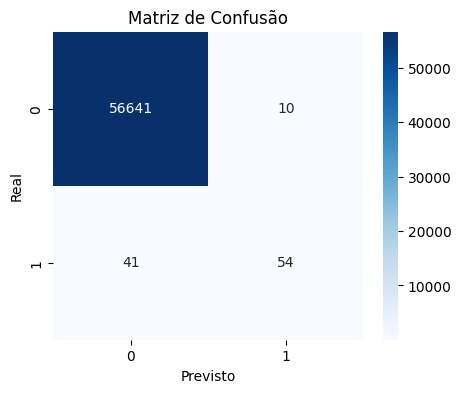

In [41]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

A matriz de confusão revela que o modelo ainda não está adequado. Apesar de ele ser bem capaz de identificar a classe de transações não fraudulentas, o que possivelmente está relacionado com o fato de essa classe conter muitas amostras, o modelo tem um problema grave, já que perdeu 41 transações que eram fraudes e previu corretamente 54. Ou seja, um valor quase equivalente ao de transações corretamente previstas foi perdido, além de o número de falsos positivos também não estar adequado.

In [39]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9993    0.9998    0.9995     56651
           1     0.8438    0.5684    0.6792        95

    accuracy                         0.9991     56746
   macro avg     0.9215    0.7841    0.8394     56746
weighted avg     0.9990    0.9991    0.9990     56746



A análise anterior é evidenciada pelo valor da métrica recall, que foi de apenas 56%, ou seja, o modelo detecta apenas 57% das fraudes reais. A precisão em si parece alta, com cerca de 84%, contudo o valor de f1-score ainda está abaixo, sendo 67%, demonstrando que o equilíbrio ainda é ruim para a classe minoritária.

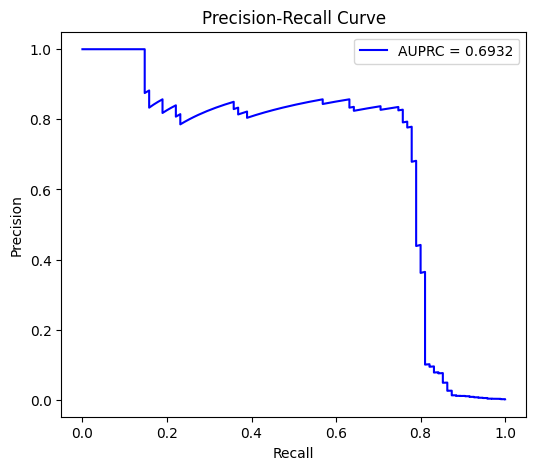

In [42]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', label=f'AUPRC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

Essa relação entre precisão e recall é interessante, pois pode ajudar a revelar o comportamento do modelo. Essa queda brusca no final do gráfico mostra que o modelo tem dificuldade para identificar casos positivos mais difíceis com muita precisão, o que pode ajudar a explicar as 41 fraudes que passaram.

Resumo: O modelo não é tão eficaz para identificar corretamente um número adequado de fraudes. Contudo, a análise indica que isso ocorre devido ao desbalanceamento massivo que existe entre as classes, o que pode ter enviesado o modelo.

Observou-se um valor de 54 fraudes corretamente identificadas, mas com um valor preocupante de 41 que foram perdidas. O modelo também apresentou 10 casos de falsos positivos e foi muito capaz de identificar a maioria das transações normais.